In [6]:
import numpy as np
from libow8 import sensor_net
import matplotlib.pyplot as plt
import owutils as ut
from designs_diag import designs, align_receiver_to_transmitter
from panel_ow import Panel

In [7]:
import numpy as np
import cma
import sys
import multiprocessing as mp
import copy

# ==========================================
# (ASSUMED IMPORTS & GLOBALS FROM YOUR ENV)
# import align_receiver_to_transmitter, sensor_net, Panel, designs ...
# ==========================================

def optimize_sensor_worker(args):
    """
    Worker function that handles the full CMA-ES loop for a single sensor.
    """
    i, r_sens, nS_sens, params_d_base, params_amb_base = args
    
    # Local cache for channel matrices to replace the old global variables
    h_ww_local = None
    h_amb_local = None

    print(f"Started Sensor {i+1} at {r_sens}...")
    sys.stdout.flush()

    def fit_function_batch_area(x_norm_batch):
        nonlocal h_ww_local, h_amb_local
        
        x = np.clip(x_norm_batch[:, 0], 0.0, 1.0)
        area = 0.001 + x * (0.3 - 0.001)
        n_particles = area.shape[0]

        # Deep copy to prevent shared dictionary modification issues
        params_amb = copy.deepcopy(params_amb_base)
        params_d = copy.deepcopy(params_d_base)

        # Fixed geometry
        r_sensor = np.tile(r_sens, (n_particles, 1))
        nR = np.tile(nS_sens, (n_particles, 1))

        for p in (params_amb, params_d):
            p['r_sensor'] = r_sensor
            p['nR_sensor'] = nR
            p['nS_sensor'] = nR
            p['A_sensor'] = area

        # Ambient
        l_amb = sensor_net(**params_amb)
        l_amb.calch(h_ww=h_amb_local)
        l_amb.light_sim()
        if h_amb_local is None:
            h_amb_local = l_amb.h_ww

        # Signal
        l = sensor_net(**params_d)
        l.calch(h_ww=h_ww_local)
        l.light_sim()
        if h_ww_local is None:
            h_ww_local = l.h_ww

        l.calc_noise()
        l.calc_rq()

        p_all = (
            np.sum(np.sum(l_amb.Pin_sm_diff, axis=0), axis=1)
            + np.sum(l_amb.Pin_sm, axis=0)
            + l_amb.Pin_sa
            + 0.5 * l.Pin_sm_tot.flatten()
        )

        G_ac = l.Pin_sm_tot.flatten() / area
        G_all = p_all / area

        snr_dB = np.zeros(n_particles)
        e_day = np.zeros(n_particles)
        bitrates = np.zeros(n_particles)

        freq = np.linspace(100, 20000, 50)

        for p_idx in range(n_particles):
            p_obj = Panel(
                area[p_idx]*1e4,
                rs=1,
                rsh=1000,
                n=1.6,
                voc=0.64,
                isc=35e-3,
                G=G_all[p_idx],
                Gac=G_ac[p_idx]
            )
            p_obj.run(False)

            ind = int(p_obj.ind)
            p_obj.calc_capacitance()
            p_obj.set_circuit(Rc=10, Lo=100e-6, Co=1000e-6)
            p_obj.find_bw()

            p_obj.tf(freq)
            p_obj.all_thermal_noise(freq)
            p_obj.shot_noise(freq)
            p_obj.vp2p(freq)

            sig = p_obj.vac[ind]
            noise = 4 * (p_obj.th_noise[ind] + p_obj.sh_noise[ind])

            if noise <= 1e-20 or sig <= 1e-20:
                snr_dB[p_idx] = -100.0
            else:
                snr_dB[p_idx] = 10 * np.log10((sig**2) / noise)

            e_day[p_idx] = p_obj.Pmax * 3600 * 8 * 0.8
            bitrates[p_idx] = np.floor(p_obj.BW[ind]) * 0.4

        l.calc_tbattery(br=bitrates)

        V = 3.3
        cycle_p = np.array([c.calc_cycle_consumption() for c in l.cycles]) * V
        cycles_day = (3600 * 24) / l.Tcycle
        e_day_c = cycles_day * cycle_p

        penalty = np.zeros(n_particles)
        penalty[snr_dB < 8.5] += (8.5 - snr_dB[snr_dB < 8.5]) * 10e4
        penalty[e_day < e_day_c] += (e_day_c[e_day < e_day_c] - e_day[e_day < e_day_c]) * 10e4
        
        return area + penalty

    # CMA-ES Setup for this specific sensor
    es = cma.CMAEvolutionStrategy(
        [0.5],
        0.25,
        {
            'popsize': 40,
            'verbose': -9,
            'maxiter': 60
        }
    )

    while not es.stop():
        solutions = es.ask()
        X = np.array(solutions)
        f = fit_function_batch_area(X)
        es.tell(solutions, f.tolist())

    best_norm = es.result.xbest[0]
    best_norm = np.clip(best_norm, 0.0, 1.0)
    area_final = 0.001 + best_norm * (0.3 - 0.001)

    print(f"-> Sensor {i+1} Done | Area={area_final*1e4:.2f} cm2 | Cost={es.result.fbest:.4f}")

    return {
        'pos': r_sens,
        'area_cm2': area_final * 1e4,
        'cost': es.result.fbest
    }

# ==========================================
# MAIN EXECUTION
# ==========================================
if __name__ == '__main__':
    KEY = 'C'
    params_d = designs[KEY]
    params_amb = designs['C'].copy()
    params_amb['r_master'] = params_d['r_lights']
    params_amb['PT_master'] = params_d['PT_lights']

    r_sen_list = designs[KEY]['r_sensor']
    nS_sen_list = np.round(
        align_receiver_to_transmitter(r_sen_list, np.array([4, 0.5, 4])), 2
    )

    N_sensors = r_sen_list.shape[0]
    print(f"Starting AREA-ONLY CMA-ES for {N_sensors} sensors on 4 cores...")

    # 1. Package arguments for the worker pool
    tasks = []
    for i in range(N_sensors):
        tasks.append((
            i,
            r_sen_list[i],
            nS_sen_list[i],
            params_d,
            params_amb
        ))

    # 2. Run multiprocessing pool with 4 cores
    with mp.Pool(processes=2) as pool:
        results = pool.map(optimize_sensor_worker, tasks)

    # 3. Save aggregated results
    np.save("area_only_cma_results_C_eight.npy", results)

    print("-" * 60)
    print("Optimization complete. Results saved to area_only_cma_results_C_eight.npy")

Starting AREA-ONLY CMA-ES for 14 sensors on 4 cores...
Started Sensor 1 at [0.2 0.1 1. ]...Started Sensor 3 at [2.73333333 0.1        1.        ]...



/home/alexandros/Επιφάνεια εργασίας/eh-ow-main (x)/eh-ow-main_8/libow8.py:42: RuntimeWarning: invalid value encountered in divide
  self.un_n1 = self.dr1 / self.abs_dr1
/home/alexandros/Επιφάνεια εργασίας/eh-ow-main (x)/eh-ow-main_8/libow8.py:42: RuntimeWarning: invalid value encountered in divide
  self.un_n1 = self.dr1 / self.abs_dr1
/home/alexandros/Επιφάνεια εργασίας/eh-ow-main (x)/eh-ow-main_8/libow8.py:43: RuntimeWarning: invalid value encountered in divide
  self.un_n2 = self.dr2 / self.abs_dr2
/home/alexandros/Επιφάνεια εργασίας/eh-ow-main (x)/eh-ow-main_8/libow8.py:43: RuntimeWarning: invalid value encountered in divide
  self.un_n2 = self.dr2 / self.abs_dr2


-> Sensor 1 Done | Area=191.28 cm2 | Cost=0.0191
Started Sensor 2 at [1.46666667 0.1        1.        ]...
-> Sensor 3 Done | Area=81.43 cm2 | Cost=0.0081
Started Sensor 4 at [4.  0.1 1. ]...
-> Sensor 4 Done | Area=70.93 cm2 | Cost=0.0071
Started Sensor 5 at [5.26666667 0.1        1.        ]...
-> Sensor 2 Done | Area=113.36 cm2 | Cost=0.0113
Started Sensor 7 at [7.8 0.1 1. ]...
-> Sensor 7 Done | Area=191.28 cm2 | Cost=0.0191
Started Sensor 8 at [0.2 0.1 3. ]...
-> Sensor 5 Done | Area=81.43 cm2 | Cost=0.0081
Started Sensor 6 at [6.53333333 0.1        1.        ]...
-> Sensor 6 Done | Area=113.36 cm2 | Cost=0.0113
Started Sensor 9 at [1.46666667 0.1        3.        ]...
-> Sensor 8 Done | Area=66.15 cm2 | Cost=0.0066
Started Sensor 11 at [4.  0.1 3. ]...
-> Sensor 9 Done | Area=54.75 cm2 | Cost=0.0055
Started Sensor 10 at [2.73333333 0.1        3.        ]...
-> Sensor 11 Done | Area=14.95 cm2 | Cost=0.0015
Started Sensor 12 at [5.26666667 0.1        3.        ]...
-> Sensor 10 Don

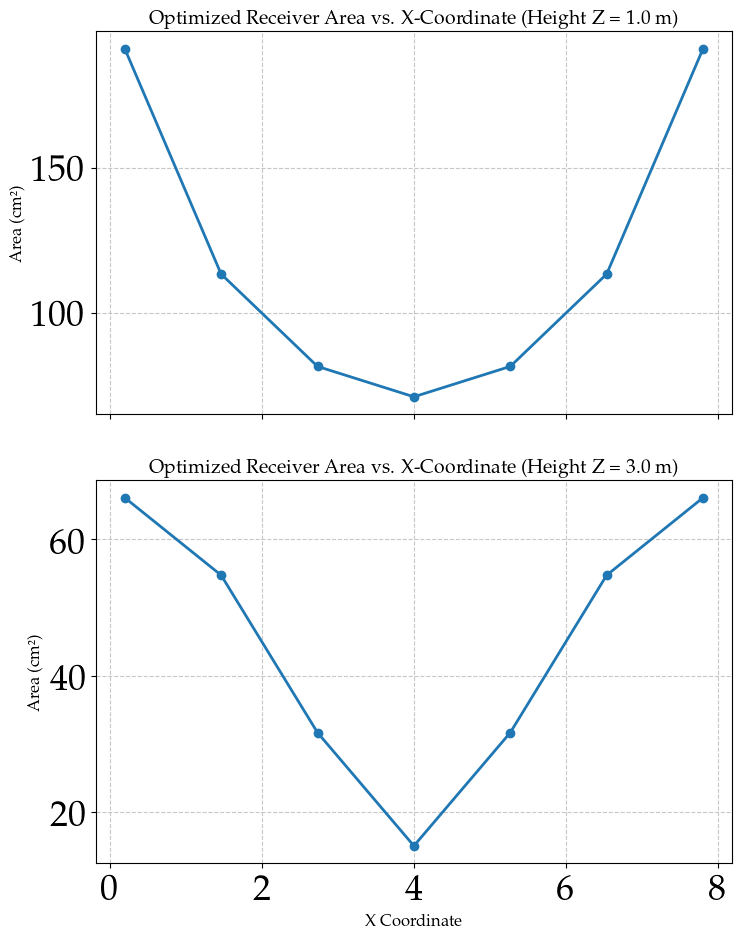

In [8]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Load the results 
# Note: allow_pickle=True is required because the array contains Python dictionaries
results = np.load("area_only_cma_results_C_eight.npy", allow_pickle=True)

# 2. Extract X, Z coordinates, and areas
x_coords = np.array([res['pos'][0] for res in results])
z_coords = np.array([res['pos'][2] for res in results]) # Extract Z (height)
areas = np.array([res['area_cm2'] for res in results])

# Get the unique heights (Z) in the data
unique_zs = np.unique(z_coords)

# 3. Create the plots (one for each unique height Z)
# We will use subplots to stack them cleanly
fig, axes = plt.subplots(len(unique_zs), 1, figsize=(8, 5 * len(unique_zs)), sharex=True)

# Handle the edge case where there might only be 1 unique Z
if len(unique_zs) == 1:
    axes = [axes]

for i, z_val in enumerate(unique_zs):
    # Filter data for this specific Z height
    mask = (z_coords == z_val)
    x_z = x_coords[mask]
    areas_z = areas[mask]
    
    # Sort the filtered data by X-coordinate
    sorted_indices = np.argsort(x_z)
    x_sorted = x_z[sorted_indices]
    areas_sorted = areas_z[sorted_indices]
    
    # Plot on the specific subplot
    axes[i].plot(x_sorted, areas_sorted, marker='o', linestyle='-', linewidth=2)
    
    # Formatting
    axes[i].set_title(f'Optimized Receiver Area vs. X-Coordinate (Height Z = {z_val} m)', fontsize=14)
    axes[i].set_ylabel('Area (cm²)', fontsize=12)
    axes[i].grid(True, linestyle='--', alpha=0.7)

# Add the X-axis label only to the bottom plot
axes[-1].set_xlabel('X Coordinate', fontsize=12)

plt.tight_layout()
plt.show()